# Analyse de stabilité de la commande latérale

Justification numérique de la section *Analyse de stabilité de la commande latérale* du rapport.
Le procédé vu par la caméra est le double intégrateur pondéré
$$P(s)=\frac{\kappa g}{z}\,\frac{1}{s^2},\qquad \kappa=\frac{1}{\tan(\mathrm{HFOV}/2)},$$
régulé par un PD $C(s)=K_p+K_d s$. On étudie successivement :
1. le modèle **continu** (lieu des racines, réponse indicielle, Bode/marges) ;
2. le modèle **échantillonné** (ZOH) et le plafond $K_d^{\mathrm{crit}}(z)=2z/(\kappa g T)$ ;
3. le **couloir de gains** latéral (plafond d'échantillonnage vs plancher de retard) ;
4. l'**écueil de dérotation** : le flux non dérotaté injecte $\dot\theta$ dans la voie D.


## 1 — Configuration et modèle continu


In [2]:
# pip install control matplotlib ipywidgets

import numpy as np
import matplotlib.pyplot as plt
import control as ct

from ipywidgets import interact, FloatSlider, IntSlider, fixed


# ==============================================================================
# CONFIG
# ==============================================================================
G = 9.80665

# --- Lateral PD gains (K_p = k_theta_p * sigma_p, K_d = k_theta_d * sigma_d) ---
KP0 = 0.44
KD0 = 0.155
H_REF0 = 5.0

# --- Camera normalised focal length: kappa = 1 / tan(HFOV/2) -------------------
# The offset is x_offset = kappa * X / z, matching the normalisation
# x_offset = (c_x - W/2)/(W/2). Set from the real horizontal FoV.
HFOV_DEG0 = 90.0
KAPPA0 = 1.0 / np.tan(np.deg2rad(HFOV_DEG0) / 2.0)   # HFOV=90deg -> kappa=1.0

# --- Sampling and delays (the ingredients of the discrete analysis) -----------
T_S0 = 0.04        # control/vision sample period [s]  (25 Hz)
TAU_PHI0 = 0.08    # inner attitude-loop time constant [s]
TAU_V0 = 0.06      # vision + processing transport delay [s]
TAU_D0 = 0.03      # derivative (flow) low-pass time constant [s]

K_MAX0 = 6.0

# Frequency range used for Nyquist and Bode plots.
# Do not start at zero: the plant contains a double integrator, so L(jw)
# goes to infinity as w -> 0.
W_MIN0 = 1e-2
W_MAX0 = 1e2


# ==============================================================================
# CONTINUOUS MODEL
# ==============================================================================
def make_pd_loop(kp, kd, h_ref, kappa=KAPPA0):
    """
    Lateral offset model seen through the camera (section: du pixel au 2nd ordre):

        xddot_offset = (kappa*g/z) * u_theta          (double integrator)
        u_theta      = -(kp*x_offset + kd*xdot_offset)

    Classical unity-feedback form:
        P(s) = Kx / s^2,   Kx = kappa*g/z
        C(s) = kd*s + kp
        L(s) = C(s)P(s),   T(s) = L/(1+L)
    """
    if h_ref <= 0:
        raise ValueError("h_ref must be positive.")

    Kx = kappa * G / h_ref

    s = ct.tf([1, 0], [1])
    P = Kx / s**2
    C = kd * s + kp
    L = C * P
    T = ct.feedback(L, 1)

    return P, C, L, T, Kx


def make_pd_loop_attitude(kp, kd, h_ref, kappa=KAPPA0, tau_phi=TAU_PHI0, tau_v=TAU_V0):
    """
    Same loop but with the finite attitude lag and vision delay made explicit:
        P(s) = (kappa*g/z) / [ s^2 (1 + tau_phi s) ] * e^{-tau_v s}
    The delay is approximated by a 2nd-order Pade for continuous-domain plots.
    """
    Kx = kappa * G / h_ref
    s = ct.tf([1, 0], [1])
    P = Kx / (s**2 * (1 + tau_phi * s))
    if tau_v > 0:
        num_p, den_p = ct.pade(tau_v, 2)
        P = P * ct.tf(num_p, den_p)
    C = kd * s + kp
    L = C * P
    T = ct.feedback(L, 1)
    return P, C, L, T, Kx


def second_order_metrics(kp, kd, h_ref, kappa=KAPPA0):
    """wn = sqrt(kappa*g*kp/z),  zeta = (kd/2) sqrt(kappa*g/(z*kp))."""
    Kx = kappa * G / h_ref
    if kp <= 0:
        return np.nan, np.nan
    wn = np.sqrt(Kx * kp)
    zeta = 0.5 * kd * np.sqrt(Kx / kp)
    return wn, zeta


def crossover_estimate(kd, h_ref, kappa=KAPPA0):
    """D-dominated crossover  wc ~ kappa*g*kd/z  (section: fréquence de coupure)."""
    return kappa * G * kd / h_ref


def kd_crit_ideal(h_ref, t_s, kappa=KAPPA0):
    """Leading-order ZOH ceiling on the derivative gain: Kd_crit = 2 z /(kappa g T)."""
    return 2.0 * h_ref / (kappa * G * t_s)


# ==============================================================================
# small compatibility + formatting helpers (kept from the original notebook)
# ==============================================================================
def get_closed_loop_poles(T):
    if hasattr(ct, "poles"):
        return ct.poles(T)
    return ct.pole(T)


def frequency_response_complex(system, omega):
    return np.array([complex(ct.evalfr(system, 1j * w)) for w in omega], dtype=complex)


def safe_stability_margins(L):
    try:
        gm, pm, wg, wp = ct.margin(L)
    except Exception:
        gm, pm, wg, wp = np.nan, np.nan, np.nan, np.nan
    return gm, pm, wg, wp


def fmt_number(value, unit="", precision=4):
    try:
        value = float(np.asarray(value).squeeze())
    except Exception:
        return str(value)
    if np.isnan(value):
        return "nan"
    if np.isposinf(value):
        return "inf"
    if np.isneginf(value):
        return "-inf"
    return f"{value:.{precision}f}{unit}"



## 2 — Modèle échantillonné (ZOH) et modèle de flux non dérotaté


In [3]:
# ==============================================================================
# DISCRETE (SAMPLED-DATA) MODEL
# ==============================================================================
# The plant is held by a zero-order hold at period T and the PD is realised as a
# discrete compensator with a *filtered* derivative (never a raw backward
# difference, which would add a full sample of lag). We then look at where a
# closed-loop pole leaves the unit circle as Kd grows -> Kd_crit(z).

def discretize_plant_zoh(h_ref, t_s, kappa=KAPPA0, tau_phi=0.0, n_delay=0):
    """
    ZOH-discretise P(s) = (kappa*g/z)/[s^2 (1+tau_phi s)] and append an integer
    transport delay z^{-n_delay}. tau_phi=0 -> pure double integrator (the clean
    teaching case that yields Kd_crit = 2z/(kappa g T)).
    """
    Kx = kappa * G / h_ref
    s = ct.tf([1, 0], [1])
    if tau_phi > 0:
        Pc = Kx / (s**2 * (1 + tau_phi * s))
    else:
        Pc = Kx / s**2
    Pd = ct.c2d(Pc, t_s, method="zoh")
    if n_delay > 0:
        z_inv = ct.tf([1], [1] + [0] * n_delay, dt=t_s)  # z^{-n_delay}
        Pd = Pd * z_inv
    return Pd


def discretize_pd(kp, kd, t_s, tau_d=TAU_D0):
    """
    Discretise C(s) = kp + kd*s/(1+tau_d s) with Tustin. Using a proper filtered
    derivative avoids the improper pure-derivative and models the flow low-pass.
    """
    # keep the derivative filter no faster than ~Nyquist so Tustin stays
    # well-conditioned (a raw/near-ideal derivative is not realisable anyway).
    tau_d = max(float(tau_d), t_s / 2.0)
    s = ct.tf([1, 0], [1])
    Cc = kp + kd * s / (1 + tau_d * s)
    return ct.c2d(Cc, t_s, method="tustin")


def discrete_loop(kp, kd, h_ref, t_s, kappa=KAPPA0,
                  tau_phi=0.0, tau_d=TAU_D0, n_delay=0):
    """Return (Pd, Cd, Ld, Td) for the sampled lateral loop."""
    Pd = discretize_plant_zoh(h_ref, t_s, kappa=kappa, tau_phi=tau_phi, n_delay=n_delay)
    Cd = discretize_pd(kp, kd, t_s, tau_d=tau_d)
    Ld = Cd * Pd
    Td = ct.feedback(Ld, 1)
    return Pd, Cd, Ld, Td


def kd_pole_sweep(kp, h_ref, t_s, kd_grid, kappa=KAPPA0,
                  tau_phi=0.0, tau_d=TAU_D0, n_delay=0):
    """
    Sweep the derivative gain Kd and collect discrete closed-loop poles.
    Returns (poles_array [n_kd x n_poles], max|pole| per Kd, Kd_crit numeric).
    Version-robust alternative to root_locus (works for any loop structure).
    """
    poles_list, max_mag = [], []
    for kd in kd_grid:
        _, _, _, Td = discrete_loop(kp, kd, h_ref, t_s, kappa=kappa,
                                    tau_phi=tau_phi, tau_d=tau_d, n_delay=n_delay)
        p = get_closed_loop_poles(Td)
        poles_list.append(p)
        max_mag.append(np.max(np.abs(p)) if len(p) else np.nan)
    max_mag = np.asarray(max_mag)

    kd_crit = np.nan
    crossings = np.where(np.diff(np.sign(max_mag - 1.0)) > 0)[0]
    if crossings.size:
        i = crossings[0]
        m0, m1 = max_mag[i], max_mag[i + 1]
        frac = (1.0 - m0) / (m1 - m0) if m1 != m0 else 0.0
        kd_crit = kd_grid[i] + frac * (kd_grid[i + 1] - kd_grid[i])

    # pad ragged pole counts for array stacking
    n = max(len(p) for p in poles_list)
    padded = np.full((len(poles_list), n), np.nan + 0j, dtype=complex)
    for r, p in enumerate(poles_list):
        padded[r, :len(p)] = p
    return padded, max_mag, kd_crit


# ==============================================================================
# UN-DEROTATED FLOW MODEL  (Écueil 2)
# ==============================================================================
# If the flow is not IMU-derotated, the D-term measures  ubar_n = xdot - kappa*thetadot.
# The characteristic equation gains an inner term:
#     1 + A(s)[ (kp+kd s) B(s) - kd*kappa*s ] = 0
# with  B(s) = (kappa g/z)/s^2 ,  A(s) = 1/(1+tau_phi s).
# The effective attitude time constant becomes tau_phi - kd*kappa -> instability
# when Kd > tau_phi/kappa.

def closed_loop_norotation(kp, kd, h_ref, kappa=KAPPA0, tau_phi=TAU_PHI0):
    Kx = kappa * G / h_ref
    s = ct.tf([1, 0], [1])
    B = Kx / s**2
    A = 1 / (1 + tau_phi * s)
    C = kp + kd * s
    Ghat = A * (C * B - kd * kappa * s)   # char. eq. is 1 + Ghat = 0
    Tnr = ct.feedback(Ghat, 1)
    return Tnr


def closed_loop_derotated(kp, kd, h_ref, kappa=KAPPA0, tau_phi=TAU_PHI0):
    Kx = kappa * G / h_ref
    s = ct.tf([1, 0], [1])
    B = Kx / s**2
    A = 1 / (1 + tau_phi * s)
    C = kp + kd * s
    L = C * B * A
    return ct.feedback(L, 1)


def kd_attitude_threshold(kappa=KAPPA0, tau_phi=TAU_PHI0):
    """Écueil 2 threshold: Kd > tau_phi / kappa destabilises the attitude loop."""
    return tau_phi / kappa



## 3 — Fonctions de tracé


In [4]:
# ==============================================================================
# PLOT 1 — CONTINUOUS EXPLORER  (root locus, step, Nyquist, Bode)
# ==============================================================================
def plot_continuous(kp=KP0, kd=KD0, h_ref=H_REF0, kappa=KAPPA0,
                    k_max=K_MAX0, w_min=W_MIN0, w_max=W_MAX0, t_end=15.0):
    P, C, L, T, Kx = make_pd_loop(kp, kd, h_ref, kappa=kappa)
    poles = get_closed_loop_poles(T)
    wn, zeta = second_order_metrics(kp, kd, h_ref, kappa=kappa)
    wc = crossover_estimate(kd, h_ref, kappa=kappa)

    w_min = max(float(w_min), 1e-6)
    w_max = max(float(w_max), 10.0 * w_min)
    omega = np.logspace(np.log10(w_min), np.log10(w_max), 1500)
    Ljw = frequency_response_complex(L, omega)
    mag_db = 20 * np.log10(np.maximum(np.abs(Ljw), 1e-300))
    phase = np.unwrap(np.angle(Ljw)) * 180 / np.pi
    gm, pm, wg, wp = safe_stability_margins(L)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    # root locus (scalar K scaling the PD)
    ax = axes[0, 0]
    gains = np.linspace(0.0, k_max, 800)
    for kk in gains[::8]:
        pp = get_closed_loop_poles(ct.feedback(kk * L, 1))
        ax.scatter(pp.real, pp.imag, s=4, color="#8bb7e8")
    ax.scatter(poles.real, poles.imag, marker="x", s=90, linewidths=2.5,
               color="#c0392b", label="current CL poles", zorder=5)
    ax.axvline(0, lw=1, alpha=.6); ax.axhline(0, lw=.8, alpha=.6)
    ax.set_title("Continuous root locus (K scales PD)")
    ax.set_xlabel("Re(s) [1/s]"); ax.set_ylabel("Im(s) [1/s]")
    ax.grid(alpha=.3); ax.legend()

    # step
    ax = axes[0, 1]
    t = np.linspace(0, t_end, 800)
    tout, yout = ct.step_response(T, T=t)
    ax.plot(tout, np.squeeze(yout), lw=1.8, color="#1f6fb2")
    ax.axhline(1, ls="--", lw=1, alpha=.7)
    ax.set_title("Closed-loop step (offset)")
    ax.set_xlabel("Time [s]"); ax.set_ylabel("normalised offset"); ax.grid(alpha=.3)

    # bode mag
    ax = axes[1, 0]
    ax.semilogx(omega, mag_db, lw=1.6, color="#1f6fb2")
    ax.axhline(0, ls=":", lw=1.1, alpha=.8)
    if np.isfinite(wc):
        ax.axvline(wc, ls="--", lw=1, color="#199e70", label=f"wc≈κg·Kd/z={wc:.2f}")
    ax.set_title("Open-loop |L(jω)|")
    ax.set_xlabel("ω [rad/s]"); ax.set_ylabel("dB"); ax.grid(which="both", alpha=.3); ax.legend(fontsize=8)

    # bode phase
    ax = axes[1, 1]
    ax.semilogx(omega, phase, lw=1.6, color="#1f6fb2")
    ax.axhline(-180, ls=":", lw=1.1, alpha=.8, label="-180°")
    ax.set_title(f"Open-loop ∠L(jω)   (PM={fmt_number(pm, '°', 1)})")
    ax.set_xlabel("ω [rad/s]"); ax.set_ylabel("phase [deg]"); ax.grid(which="both", alpha=.3); ax.legend(fontsize=8)

    stable = np.all(np.real(poles) < 0)
    fig.suptitle(f"CONTINUOUS | kp={kp:.3f} kd={kd:.3f} z={h_ref:.2f}m κ={kappa:.3f} "
                 f"Kx={Kx:.3f} | wn={wn:.3f} ζ={zeta:.3f} stable={stable}", fontsize=10)
    fig.tight_layout(); plt.show()
    print(f"wn={wn:.4f} rad/s ({wn/2/np.pi:.4f} Hz) | ζ={zeta:.4f} | "
          f"wc≈{wc:.4f} rad/s | PM={fmt_number(pm,'°',2)} | "
          f"Kd/Kp={kd/kp:.4f} s (needs > τ_tot)")


# ==============================================================================
# PLOT 2 — DISCRETE EXPLORER  (Kd root locus in z-plane at TWO heights)
# ==============================================================================
def plot_discrete(kp=KP0, h_ref=H_REF0, t_s=T_S0, kappa=KAPPA0,
                  tau_phi=0.0, tau_d=TAU_D0, n_delay=0,
                  kd=KD0, kd_max=1.2, h_low=1.0):
    kd_grid = np.linspace(1e-4, kd_max, 400)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.4))

    for ax, z in zip(axes, [h_ref, h_low]):
        poles, mag, kd_crit = kd_pole_sweep(kp, z, t_s, kd_grid, kappa=kappa,
                                            tau_phi=tau_phi, tau_d=tau_d, n_delay=n_delay)
        th = np.linspace(0, 2 * np.pi, 200)
        ax.plot(np.cos(th), np.sin(th), color="#888", lw=1)
        for b in range(poles.shape[1]):
            sc = ax.scatter(poles[:, b].real, poles[:, b].imag,
                            c=kd_grid, cmap="viridis", s=6)
        kd_ideal = kd_crit_ideal(z, t_s, kappa=kappa)
        ax.set_title(f"z={z:.2f} m   Kd_crit(num)={fmt_number(kd_crit)}  "
                     f"2z/(κgT)={kd_ideal:.3f}")
        ax.set_xlabel("Re(w)"); ax.set_ylabel("Im(w)")
        ax.set_aspect("equal", "box"); ax.grid(alpha=.3)
        ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
    cb = fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=.85)
    cb.set_label("Kd")
    fig.suptitle(f"DISCRETE Kd-locus (ZOH, T={t_s*1e3:.0f} ms, τφ={tau_phi*1e3:.0f} ms, "
                 f"n_delay={n_delay}) — poles leave |w|=1 → oscillation", fontsize=10)
    plt.show()


# ==============================================================================
# PLOT 3 — LATERAL GAIN BAND  (Kd ceiling ∝ z  vs  Kd/Kp>τ_tot floor)
# ==============================================================================
def plot_gain_band(kp=KP0, t_s=T_S0, kappa=KAPPA0, tau_phi=0.0, tau_d=TAU_D0,
                   n_delay=0, tau_tot=None, z_max=6.0):
    if tau_tot is None:
        tau_tot = TAU_V0 + tau_phi + t_s / 2 + tau_d
    zs = np.linspace(0.15, z_max, 40)

    ceil_ideal = kd_crit_ideal(zs, t_s, kappa=kappa)
    ceil_num = []
    kd_grid = np.linspace(1e-4, 1.5 * kd_crit_ideal(z_max, t_s, kappa=kappa), 300)
    for z in zs:
        _, _, kdc = kd_pole_sweep(kp, z, t_s, kd_grid, kappa=kappa,
                                  tau_phi=tau_phi, tau_d=tau_d, n_delay=n_delay)
        ceil_num.append(kdc)
    ceil_num = np.asarray(ceil_num)
    floor = tau_tot * kp * np.ones_like(zs)   # Kd > tau_tot*Kp

    fig, ax = plt.subplots(figsize=(8.2, 5.2))
    ax.plot(zs, ceil_ideal, color="#c0392b", lw=2,
            label=r"ceiling $2z/(\kappa g T)$ (ideal)")
    ax.plot(zs, ceil_num, color="#c0392b", lw=1.6, ls="--",
            label="ceiling (numeric, with τφ/delay)")
    ax.plot(zs, floor, color="#ba7517", lw=2, label=r"floor $\tau_{tot}K_p$  (Kd/Kp>τtot)")
    ax.fill_between(zs, floor, ceil_num, where=(ceil_num > floor),
                    color="#199e70", alpha=.15, label="admissible band")
    ax.set_xlabel("height z [m]"); ax.set_ylabel("derivative gain Kd [s]")
    ax.set_title(f"Lateral Kd corridor (Kp={kp:.3f}, T={t_s*1e3:.0f} ms, "
                 f"τ_tot={tau_tot*1e3:.0f} ms, κ={kappa:.2f})")
    ax.grid(alpha=.3); ax.legend(fontsize=9); ax.set_ylim(bottom=0)
    plt.show()


# ==============================================================================
# PLOT 4 — DEROTATION COMPARISON  (Écueil 2)
# ==============================================================================
def plot_derotation(kp=KP0, kd=KD0, h_ref=H_REF0, kappa=KAPPA0,
                    tau_phi=TAU_PHI0, t_end=6.0):
    thr = kd_attitude_threshold(kappa=kappa, tau_phi=tau_phi)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # (a) attitude-pole real part vs Kd, derotated vs not
    ax = axes[0]
    kd_grid = np.linspace(0, 2.5 * thr, 200)
    worst_nr, worst_dr = [], []
    for k in kd_grid:
        pnr = get_closed_loop_poles(closed_loop_norotation(kp, k, h_ref, kappa, tau_phi))
        pdr = get_closed_loop_poles(closed_loop_derotated(kp, k, h_ref, kappa, tau_phi))
        worst_nr.append(np.max(pnr.real)); worst_dr.append(np.max(pdr.real))
    ax.plot(kd_grid, worst_nr, color="#c0392b", lw=1.8, label="flux NON dérotaté")
    ax.plot(kd_grid, worst_dr, color="#1f6fb2", lw=1.8, label="flux dérotaté")
    ax.axhline(0, ls=":", color="k", lw=1)
    ax.axvline(thr, ls="--", color="#c0392b", lw=1.2, label=f"Kd=τφ/κ={thr:.3f}")
    ax.set_xlabel("Kd [s]"); ax.set_ylabel("max Re(pole) [1/s]")
    ax.set_title("Worst closed-loop pole real part")
    ax.grid(alpha=.3); ax.legend(fontsize=8)

    # (b) step responses at current Kd
    ax = axes[1]
    t = np.linspace(0, t_end, 700)
    for lbl, Tcl, col in [("non dérotaté", closed_loop_norotation(kp, kd, h_ref, kappa, tau_phi), "#c0392b"),
                          ("dérotaté", closed_loop_derotated(kp, kd, h_ref, kappa, tau_phi), "#1f6fb2")]:
        try:
            to, yo = ct.step_response(Tcl, T=t)
            ax.plot(to, np.squeeze(yo), lw=1.8, label=lbl, color=col)
        except Exception:
            pass
    ax.axhline(1, ls="--", lw=1, alpha=.6)
    ax.set_xlabel("Time [s]"); ax.set_ylabel("normalised offset")
    ax.set_title(f"Step at Kd={kd:.3f} (threshold τφ/κ={thr:.3f})")
    ax.grid(alpha=.3); ax.legend(fontsize=8)

    fig.suptitle("Écueil 2 — un-derotated flow feeds pitch rate into the D-channel", fontsize=10)
    fig.tight_layout(); plt.show()



## 4 — Explorateur continu

Lieu des racines, réponse indicielle et Bode de $L(s)=C(s)P(s)$. On lit $\omega_n$, $\zeta$, la
coupure $\omega_c\approx\kappa gK_d/z$ et la marge de phase. Vérifier la condition $K_d/K_p>\tau_{\mathrm{tot}}$.


In [ ]:
interact(
    plot_continuous,
    kp=FloatSlider(value=KP0, min=0.01, max=3, step=0.11, description="Kp"),
    kd=FloatSlider(value=KD0, min=0.0, max=3, step=0.1, description="Kd"),
    h_ref=FloatSlider(value=H_REF0, min=1.0, max=10.0, step=0.25, description="z [m]"),
    kappa=FloatSlider(value=KAPPA0, min=0.5, max=3.0, step=0.05, description="kappa"),
    k_max=fixed(K_MAX0), w_min=fixed(W_MIN0), w_max=fixed(W_MAX0), t_end=fixed(15.0),
);



interactive(children=(FloatSlider(value=0.44, description='Kp', max=3.0, min=0.01, step=0.11), FloatSlider(val…

## 5 — Lieu des racines discret en $K_d$ (deux hauteurs)

Le pendant latéral des figures de de Croon. À gain $K_d$ croissant, une **paire de pôles complexes**
quitte le cercle unité (oscillation à $\approx f_s/4$). Le seuil numérique est comparé à $2z/(\kappa g T)$.


In [ ]:
interact(
    plot_discrete,
    kp=FloatSlider(value=KP0, min=0.0, max=1.5, step=0.01, description="Kp"),
    h_ref=FloatSlider(value=H_REF0, min=1.0, max=10.0, step=0.25, description="z_haut [m]"),
    h_low=FloatSlider(value=1.0, min=0.3, max=5.0, step=0.1, description="z_bas [m]"),
    t_s=FloatSlider(value=T_S0, min=0.01, max=0.12, step=0.005, description="T [s]"),
    kappa=FloatSlider(value=KAPPA0, min=0.5, max=3.0, step=0.05, description="kappa"),
    tau_phi=FloatSlider(value=0.0, min=0.0, max=0.2, step=0.01, description="tau_phi [s]"),
    tau_d=fixed(TAU_D0),
    n_delay=IntSlider(value=0, min=0, max=6, step=1, description="n_delay"),
    kd=fixed(KD0),
    kd_max=FloatSlider(value=30.0, min=2.0, max=60.0, step=1.0, description="Kd max"),
);



interactive(children=(FloatSlider(value=0.44, description='Kp', max=1.5, step=0.01), FloatSlider(value=5.0, de…

## 6 — Couloir de gains latéral

Plafond d'échantillonnage $K_d^{\mathrm{crit}}(z)=2z/(\kappa g T)$ (idéal et numérique) contre
plancher de retard $K_d>\tau_{\mathrm{tot}}K_p$. Zone admissible en vert — analogue du couloir vertical de la section 6.


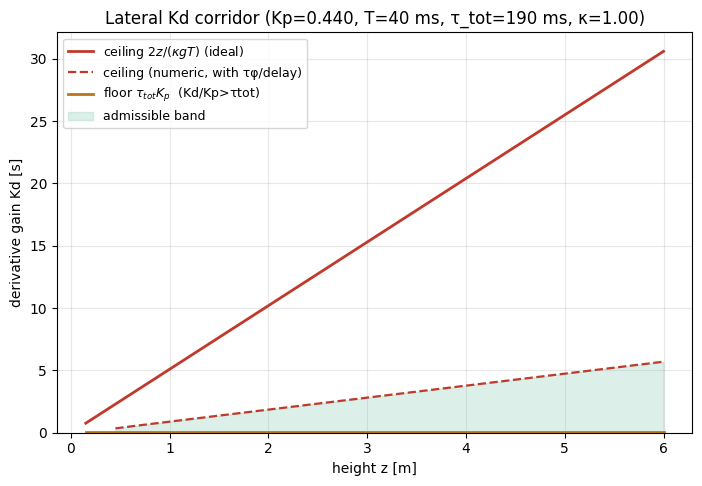

In [7]:
plot_gain_band(kp=KP0, t_s=T_S0, kappa=KAPPA0, tau_phi=TAU_PHI0, n_delay=round(TAU_V0/T_S0))



## 7 — Écueil 2 : flux non dérotaté

Sans dérotation IMU, la mesure de flux vaut $\bar u_n^{\mathrm{mes}}=\dot x_{\mathrm{offset}}-\kappa\dot\theta$ :
la voie D referme $\dot\theta$ dans la boucle d'attitude et déstabilise dès $K_d>\tau_\phi/\kappa$.
À gauche : partie réelle du pire pôle. À droite : réponses indicielles comparées.


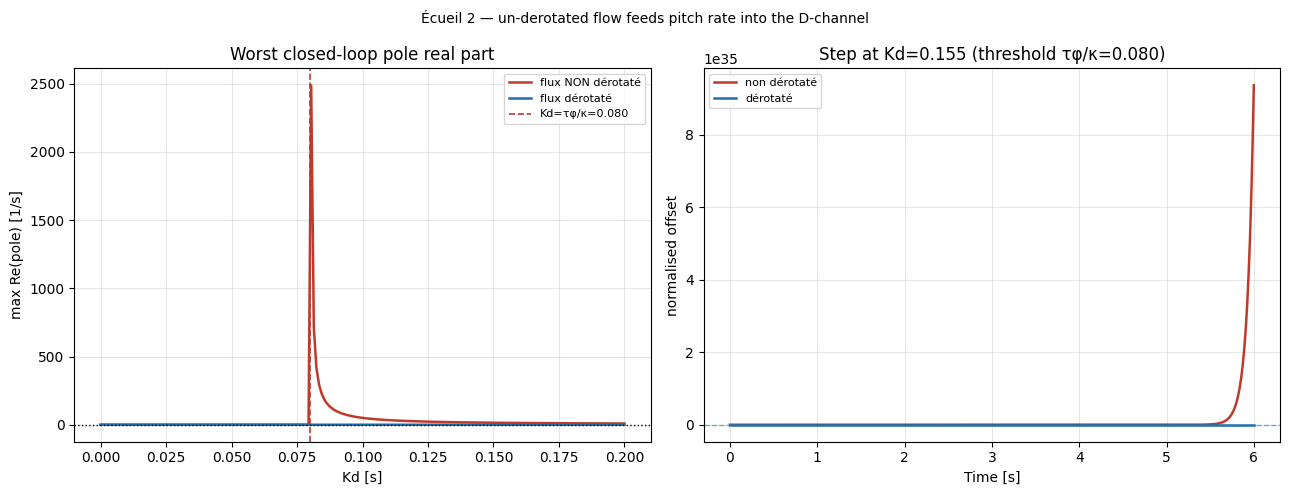

In [8]:
plot_derotation(kp=KP0, kd=KD0, h_ref=H_REF0, kappa=KAPPA0, tau_phi=TAU_PHI0)

